# CURB - Curb Intelligence System
### Analysis & metrics notebook - Problem Statement 1 (Parking-Induced Congestion)

This notebook runs the full CURB pipeline end-to-end on the **provided** Bengaluru
parking-violation dataset and reports verifiable metrics at each stage:

1. **Load & clean** - coverage and data-quality metrics
2. **Exploratory data analysis** - what's in the data (incl. an honest temporal caveat)
3. **Hotspots + congestion-impact model** - concentration metrics, rank-shift vs naive counts
4. **Root-cause classification** - distribution + an exploratory k-means with a silhouette score
5. **Metrics summary**

Everything traces back to a single provided CSV; all weights are transparent constants in `config.py`.

In [31]:
# --- setup: make the repo modules importable, set the data path ---
import os, sys, time, json
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "config.py").exists() and (REPO_ROOT.parent / "config.py").exists():
    REPO_ROOT = REPO_ROOT.parent          # launched from inside notebooks/
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import config
DATA_PATH = config.DATA_PATH              # data/violations.csv by default
print("repo root :", REPO_ROOT)
print("data path :", DATA_PATH, "(exists:", os.path.exists(DATA_PATH), ")")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 45)

repo root : C:\Users\ARPIT\Downloads\curb_source\curb
data path : data/violations.csv (exists: True )


## 1 - Load & clean\nMetrics: how many records survive cleaning, geo-coverage, and the date span.

In [32]:
from src.data_loader import load_and_clean

t0 = time.time()
df = load_and_clean(DATA_PATH)
load_secs = time.time() - t0

raw = pd.read_csv(DATA_PATH, usecols=["latitude"]).shape[0]
dt = pd.to_datetime(df["created_datetime"], errors="coerce", utc=True)

clean_metrics = {
    "raw_rows": raw,
    "usable_rows": len(df),
    "dropped_pct": round((raw - len(df)) / raw * 100, 1),
    "geo_tagged_pct": round(df[["latitude", "longitude"]].notna().all(axis=1).mean() * 100, 1),
    "date_min": str(dt.min().date()),
    "date_max": str(dt.max().date()),
    "span_days": int((dt.max() - dt.min()).days),
    "police_stations": int(df["police_station"].nunique()),
    "junctions": int(df["junction_name"].nunique()),
    "load_seconds": round(load_secs, 1),
}
pd.Series(clean_metrics)

[data] loaded 298,450 rows -> 248,376 usable after cleaning


raw_rows               298450
usable_rows            248376
dropped_pct              16.8
geo_tagged_pct          100.0
date_min           2023-11-09
date_max           2024-04-08
span_days                 150
police_stations            54
junctions                 169
load_seconds              1.8
dtype: object

## 2 - Exploratory data analysis

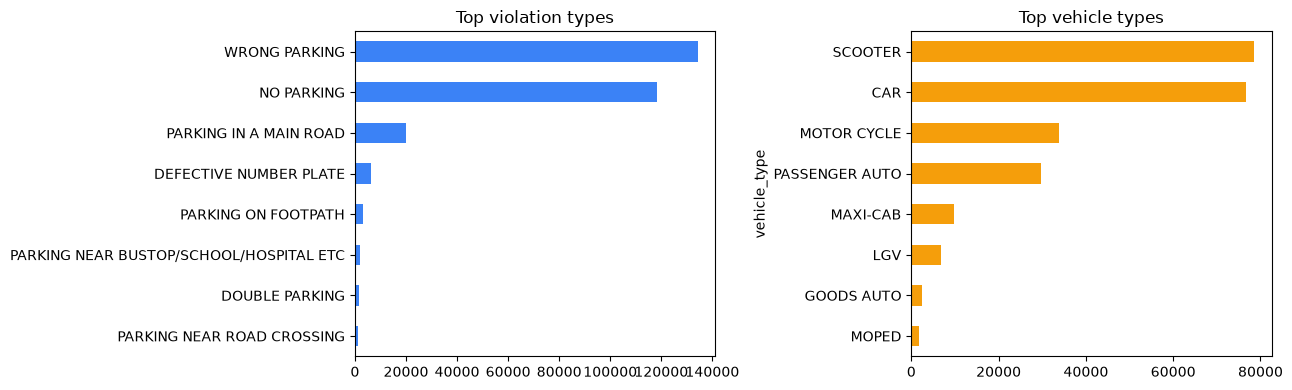

Parking-related share of all violation tags: 97.5%
Multi-violation rows: 13.2%


In [33]:
from collections import Counter
vc = Counter(v for L in df["violations"] for v in L)
viol = pd.Series(dict(vc)).sort_values(ascending=False)
veh = df["vehicle_type"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
viol.head(8).iloc[::-1].plot.barh(ax=ax[0], color="#3b82f6"); ax[0].set_title("Top violation types")
veh.head(8).iloc[::-1].plot.barh(ax=ax[1], color="#f59e0b");   ax[1].set_title("Top vehicle types")
plt.tight_layout(); plt.show()

park = [i for i in viol.index if "PARK" in i]
print(f"Parking-related share of all violation tags: {viol[park].sum()/viol.sum()*100:.1f}%")
print(f"Multi-violation rows: {df['violations'].apply(len).gt(1).mean()*100:.1f}%")

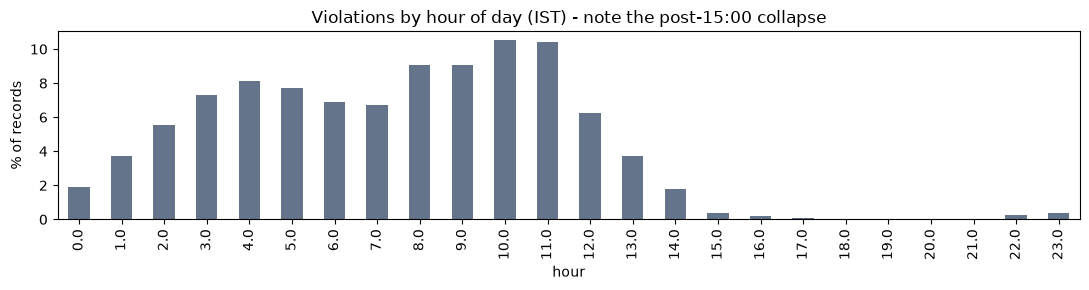

Caveat: the evening peak is absent -> timestamps were shifted in anonymisation.
=> we rely on the SPATIAL signal, not hour-of-day forecasting.


In [34]:
# HONEST temporal caveat: convert to IST and show the hour distribution
ist = dt.dt.tz_convert("Asia/Kolkata")
hourly = ist.dt.hour.value_counts(normalize=True).sort_index() * 100
ax = hourly.plot.bar(figsize=(11, 3), color="#64748b")
ax.set_title("Violations by hour of day (IST) - note the post-15:00 collapse")
ax.set_xlabel("hour"); ax.set_ylabel("% of records"); plt.tight_layout(); plt.show()
print("Caveat: the evening peak is absent -> timestamps were shifted in anonymisation.")
print("=> we rely on the SPATIAL signal, not hour-of-day forecasting.")

## 3 - Hotspots + congestion-impact model

impact(cell) = sum over rows of (violation severity) x (vehicle footprint)

Two validation metrics:
- **Concentration (Pareto):** share of total city impact captured by the top-N cells - high concentration means enforcement can be sharply targeted.
- **Rank-shift:** how much the impact model reorders hotspots vs a naive violation count (if it barely moves, the model adds nothing).

In [35]:
from src.hotspots import build_hotspots
from scipy.stats import spearmanr

t0 = time.time()
hot = build_hotspots(df)
build_secs = time.time() - t0

total_impact = hot["impact_score"].sum()
def top_share(n): return hot.head(n)["impact_score"].sum() / total_impact * 100
concentration = {f"top_{n}_cells_capture_pct_impact": round(top_share(n), 1)
                 for n in (25, 50, 100, 250)}
pd.Series(concentration)

[hotspots] 13,782 candidate cells built


top_25_cells_capture_pct_impact      9.5
top_50_cells_capture_pct_impact     14.5
top_100_cells_capture_pct_impact    22.0
top_250_cells_capture_pct_impact    35.9
dtype: float64

Spearman rank correlation (impact vs count): 0.912
Cells in the impact top-20 that are NOT in the count top-20: 11/20


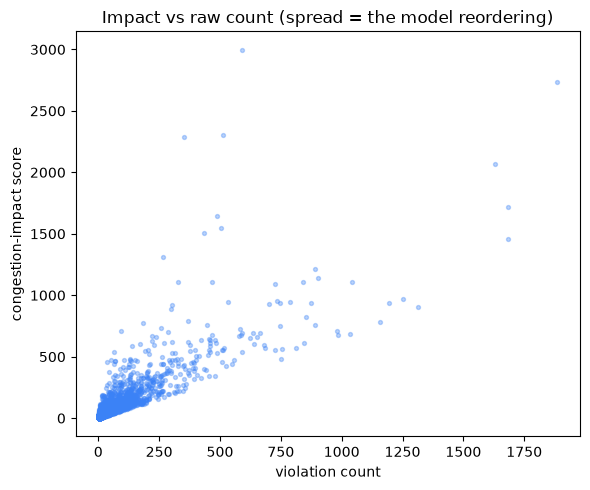

In [36]:
# rank-shift: impact ranking vs naive count ranking
naive = hot.sort_values("violations", ascending=False).reset_index(drop=True)
naive["count_rank"] = naive.index + 1
merged = hot.merge(naive[["clat", "clon", "count_rank"]], on=["clat", "clon"])
rho, _ = spearmanr(merged["rank"], merged["count_rank"])

top_impact = set(hot.head(20)[["clat", "clon"]].apply(tuple, axis=1))
top_count  = set(naive.head(20)[["clat", "clon"]].apply(tuple, axis=1))
new_in_top20 = len(top_impact - top_count)

print(f"Spearman rank correlation (impact vs count): {rho:.3f}")
print(f"Cells in the impact top-20 that are NOT in the count top-20: {new_in_top20}/20")

plt.figure(figsize=(6, 5))
plt.scatter(hot["violations"], hot["impact_score"], s=8, alpha=.35, color="#3b82f6")
plt.xlabel("violation count"); plt.ylabel("congestion-impact score")
plt.title("Impact vs raw count (spread = the model reordering)"); plt.tight_layout(); plt.show()

In [37]:
hot.head(15)[["rank", "name", "violations", "impact_score"]]

,rank,name,violations,impact_score
0,1,"Kadubeesanahalli Underpass, Kadubisanaha...",589,2997.54
1,2,BTP051 - Safina Plaza Junction,1885,2735.50
2,3,"Kadubeesanahalli Underpass, Kadubisanaha...",511,2305.32
3,4,"MBT Road, Tin Factory Junction",353,2288.16
4,5,BTP211 - Central Street Junction,1631,2066.75
5,6,"New Horizon College Road, New Horizon Co...",1685,1714.47
6,7,"Outer Ring Road, Venkatappa Colony",489,1644.91
7,8,"Unnamed Road, Begur Chikkanahalli",503,1547.38
8,9,"Old Madras Road, Royal Heritage",435,1506.22
9,10,"Bellary Road, Vinayaka Nagar",1682,1459.09


## 4 - Root-cause classification

[rootcause] labelled — distribution:
             6,040  Enforcement priority
             3,288  Commuter overflow
             2,334  Delivery overflow
             1,956  Hire / transit demand
               162  Safety risk
                 2  Structural demand


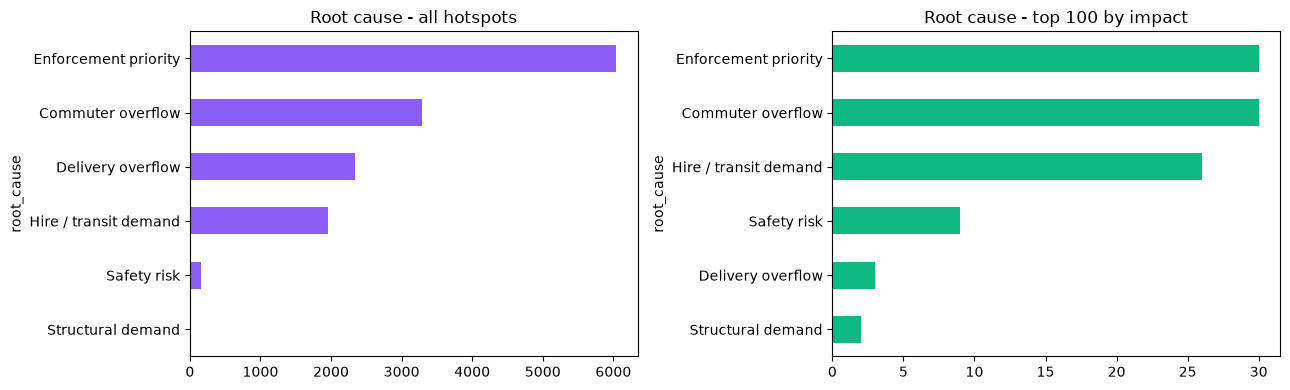

,rank,name,violations,impact_score,root_cause,recommended_fix
0,1,"Kadubeesanahalli Underpass, Kadubisanaha...",589,2997.54,Enforcement priority,Ranked patrol dispatch
1,2,BTP051 - Safina Plaza Junction,1885,2735.50,Hire / transit demand,Designated auto/cab stand + drop-off zone
2,3,"Kadubeesanahalli Underpass, Kadubisanaha...",511,2305.32,Enforcement priority,Ranked patrol dispatch
3,4,"MBT Road, Tin Factory Junction",353,2288.16,Safety risk,Bollards / physical barrier + enforcement
4,5,BTP211 - Central Street Junction,1631,2066.75,Hire / transit demand,Designated auto/cab stand + drop-off zone
5,6,"New Horizon College Road, New Horizon Co...",1685,1714.47,Commuter overflow,Park-and-ride signage + reroute to legal ...
6,7,"Outer Ring Road, Venkatappa Colony",489,1644.91,Hire / transit demand,Designated auto/cab stand + drop-off zone
7,8,"Unnamed Road, Begur Chikkanahalli",503,1547.38,Hire / transit demand,Designated auto/cab stand + drop-off zone
8,9,"Old Madras Road, Royal Heritage",435,1506.22,Enforcement priority,Ranked patrol dispatch
9,10,"Bellary Road, Vinayaka Nagar",1682,1459.09,Commuter overflow,Park-and-ride signage + reroute to legal ...


In [38]:
from src.rootcause import classify
hot = classify(hot)

dist = hot["root_cause"].value_counts()
top100 = hot.head(100)["root_cause"].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
dist.iloc[::-1].plot.barh(ax=ax[0], color="#8b5cf6"); ax[0].set_title("Root cause - all hotspots")
top100.iloc[::-1].plot.barh(ax=ax[1], color="#10b981"); ax[1].set_title("Root cause - top 100 by impact")
plt.tight_layout(); plt.show()
hot.head(10)[["rank", "name", "violations", "impact_score", "root_cause", "recommended_fix"]]

### 4b - Exploratory: do the causes show up unsupervised?
The labels above are rule-based (transparent, defensible). As a *check*, we run
k-means on each cell's feature vector and report a **silhouette score** - a real,
quantitative measure of how well-separated the discovered archetypes are.

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

hot["impact_per_violation"] = hot["impact_score"] / hot["violations"]
hot["safety_rate"] = hot["safety_hits"] / hot["violations"]
feat = ["two_share", "goods_share", "hire_share", "impact_per_violation", "safety_rate"]
X = StandardScaler().fit_transform(hot[feat].fillna(0))

scores = {}
for k in range(3, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    scores[k] = round(silhouette_score(X, km.labels_, sample_size=5000, random_state=42), 3)
print("silhouette score by k:", scores)
best_k = max(scores, key=scores.get)
print("best k:", best_k, "-> silhouette", scores[best_k])

silhouette score by k: {3: 0.395, 4: 0.426, 5: 0.493, 6: 0.508, 7: 0.512}
best k: 7 -> silhouette 0.512


## 5 - Metrics summary\nOne consolidated, reproducible scorecard for the deck / submission.

In [40]:
summary = {
    **clean_metrics,
    "hotspot_cells": len(hot),
    "build_seconds": round(build_secs, 1),
    **concentration,
    "impact_vs_count_spearman": round(float(rho), 3),
    "new_cells_in_impact_top20": new_in_top20,
    "root_cause_classes": int(hot["root_cause"].nunique()),
    "best_kmeans_silhouette": scores[best_k],
}
print(json.dumps(summary, indent=2))
pd.Series(summary).to_frame("value")

{
  "raw_rows": 298450,
  "usable_rows": 248376,
  "dropped_pct": 16.8,
  "geo_tagged_pct": 100.0,
  "date_min": "2023-11-09",
  "date_max": "2024-04-08",
  "span_days": 150,
  "police_stations": 54,
  "junctions": 169,
  "load_seconds": 1.8,
  "hotspot_cells": 13782,
  "build_seconds": 6.2,
  "top_25_cells_capture_pct_impact": 9.5,
  "top_50_cells_capture_pct_impact": 14.5,
  "top_100_cells_capture_pct_impact": 22.0,
  "top_250_cells_capture_pct_impact": 35.9,
  "impact_vs_count_spearman": 0.912,
  "new_cells_in_impact_top20": 11,
  "root_cause_classes": 6,
  "best_kmeans_silhouette": 0.512
}


,value
raw_rows,298450
usable_rows,248376
dropped_pct,16.8
geo_tagged_pct,100.0
date_min,2023-11-09
date_max,2024-04-08
span_days,150
police_stations,54
junctions,169
load_seconds,1.8
